In [5]:
#IMPORT OPERATIONS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [8]:
#IRIS DATASET

print("===== IRIS DATASET =====")

df = pd.read_csv("iris (1).csv")
df.columns = df.columns.str.strip()

X = df.drop('species', axis=1)
y = df['species']

# Encode target
le = LabelEncoder()
y = le.fit_transform(y)

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Choose K
k = int(np.sqrt(len(X_train)))
print("Chosen K:", k)

# Train
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

# Predict
y_pred = knn.predict(X_test)

# Results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))


===== IRIS DATASET =====
Chosen K: 10
Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [9]:
#DIABETES DATASET

print("\n===== DIABETES DATASET =====")

df = pd.read_csv("diabetes.csv")
df.columns = df.columns.str.strip()

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Scale
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Choose K
k = int(np.sqrt(len(X_train)))
print("Chosen K:", k)

# Train
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

# Predict
y_pred = knn.predict(X_test)

# Results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))



===== DIABETES DATASET =====
Chosen K: 24
Accuracy: 0.7467532467532467
Confusion Matrix:
 [[89 10]
 [29 26]]



===== HEART DATASET =====
Best K: 6
Accuracy: 0.9344262295081968


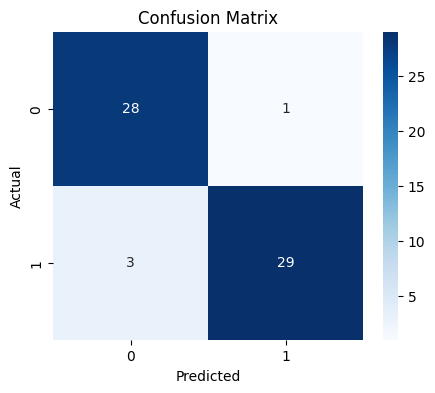

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.97      0.93        29
           1       0.97      0.91      0.94        32

    accuracy                           0.93        61
   macro avg       0.93      0.94      0.93        61
weighted avg       0.94      0.93      0.93        61



In [10]:
#HEART DATASET

print("\n===== HEART DATASET =====")

df = pd.read_csv("heart.csv")
df.columns = df.columns.str.strip()

X = df.drop("target", axis=1)
y = df["target"]

# Scale
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Find best K
scores = []
k_range = range(1, 21)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    scores.append(knn.score(X_test, y_test))

best_k = k_range[np.argmax(scores)]
print("Best K:", best_k)

# Train final model
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

# Predict
y_pred = knn.predict(X_test)

# Results
print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Classification Report:\n", classification_report(y_test, y_pred))